# AI Interview Question Generator for Interns


## Import Libraries


In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## Load the Datasets



In [6]:
intern_profiles = pd.read_csv("intern_profiles.csv")
job_descriptions = pd.read_csv("job_descriptions.csv")
question_bank = pd.read_csv("interview_question_bank.csv")

print("Intern Profiles:", intern_profiles.shape)
print("Job Descriptions:", job_descriptions.shape)
print("Question Bank:", question_bank.shape)

display(intern_profiles.head())
display(job_descriptions.head())
display(question_bank.head())


Intern Profiles: (100, 6)
Job Descriptions: (5, 4)
Question Bank: (65, 6)


,intern_id,intern_name,target_role,skills,experience_level,projects_completed
0,INT001,Intern E,Python Developer Intern,"SQL, Python, Communication",Beginner,4
1,INT002,Intern E,Web Developer Intern,"HTML, APIs, Communication",Beginner,5
2,INT003,Intern A,Database Intern,"MySQL, Python, Database",Beginner,5
3,INT004,Intern C,Web Developer Intern,"JavaScript, CSS, HTML",Beginner,0
4,INT005,Intern A,Web Developer Intern,"JavaScript, APIs",Intermediate,3


,job_id,job_title,required_skills,job_description
0,JOB001,Python Developer Intern,"Python, Pandas, SQL, Git",We are looking for a Python Developer Intern t...
1,JOB002,Data Science Intern,"Python, Pandas, NumPy, Machine Learning, SQL",We are looking for a Data Science Intern to su...
2,JOB003,Machine Learning Intern,"Python, Scikit-learn, Machine Learning, Pandas...",We are looking for a Machine Learning Intern t...
3,JOB004,Web Developer Intern,"HTML, CSS, JavaScript, Git, APIs",We are looking for a Web Developer Intern to s...
4,JOB005,Database Intern,"SQL, MySQL, Database, Python",We are looking for a Database Intern to suppor...


,question_id,question_type,role,difficulty,skill,question
0,Q001,Technical,Python Developer Intern,Intermediate,Python,What is the difference between a list and a tu...
1,Q002,Technical,Python Developer Intern,Intermediate,SQL,How would you handle missing values using Pandas?
2,Q003,Technical,Python Developer Intern,Intermediate,SQL,What is a Python dictionary and when would you...
3,Q004,Technical,Python Developer Intern,Intermediate,Python,How would you find duplicate values in a Pytho...
4,Q005,Technical,Python Developer Intern,Beginner,SQL,What is the purpose of exception handling in P...


## Understand the Data


In [7]:
print("Missing values:")
print(intern_profiles.isnull().sum())
print()
print(job_descriptions.isnull().sum())
print()
print(question_bank.isnull().sum())


Missing values:
intern_id             0
intern_name           0
target_role           0
skills                0
experience_level      0
projects_completed    0
dtype: int64

job_id             0
job_title          0
required_skills    0
job_description    0
dtype: int64

question_id      0
question_type    0
role             0
difficulty       0
skill            0
question         0
dtype: int64


## Simple Exploratory Data Analysis

First, let's see how many technical and behavioral questions are available.


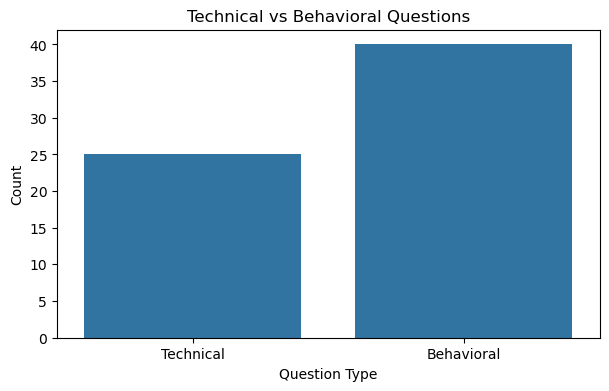

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=question_bank, x="question_type")
plt.title("Technical vs Behavioral Questions")
plt.xlabel("Question Type")
plt.ylabel("Count")
plt.show()


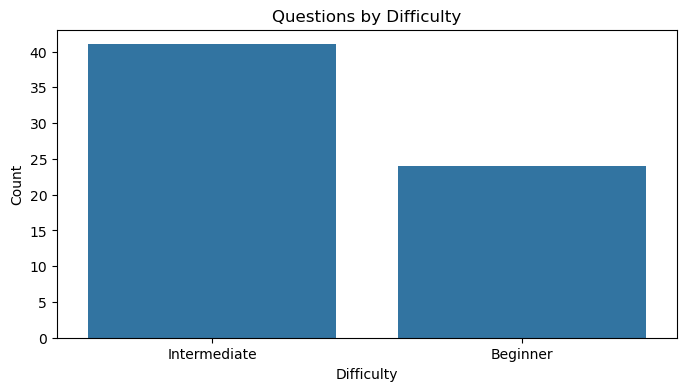

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=question_bank, x="difficulty")
plt.title("Questions by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Count")
plt.show()


## Select an Intern and Job Description



In [10]:
selected_intern_id = "INT001"

intern = intern_profiles[intern_profiles["intern_id"] == selected_intern_id].iloc[0]

role = intern["target_role"]
job = job_descriptions[job_descriptions["job_title"] == role].iloc[0]

print("Selected Intern:")
print(intern)
print("\nMatching Job:")
print(job)


Selected Intern:
intern_id                                 INT001
intern_name                             Intern E
target_role              Python Developer Intern
skills                SQL, Python, Communication
experience_level                        Beginner
projects_completed                             4
Name: 0, dtype: object

Matching Job:
job_id                                                        JOB001
job_title                                    Python Developer Intern
required_skills                             Python, Pandas, SQL, Git
job_description    We are looking for a Python Developer Intern t...
Name: 0, dtype: object


## Calculate Skill Match


In [11]:
def clean_skill_list(text):
    return {x.strip().lower() for x in str(text).split(",") if x.strip()}

intern_skills = clean_skill_list(intern["skills"])
required_skills = clean_skill_list(job["required_skills"])

matched_skills = intern_skills.intersection(required_skills)
missing_skills = required_skills - intern_skills

skill_match_score = (len(matched_skills) / len(required_skills)) * 100

print("Intern skills:", sorted(intern_skills))
print("Required skills:", sorted(required_skills))
print("Matched skills:", sorted(matched_skills))
print("Skills to improve:", sorted(missing_skills))
print(f"Skill Match Score: {skill_match_score:.2f}%")


Intern skills: ['communication', 'python', 'sql']
Required skills: ['git', 'pandas', 'python', 'sql']
Matched skills: ['python', 'sql']
Skills to improve: ['git', 'pandas']
Skill Match Score: 50.00%


## TF-IDF Similarity

### What is TF-IDF?

TF-IDF converts text into numbers based on how important words are.

### What is cosine similarity?

Cosine similarity measures how similar two pieces of text are.

We use it to find questions that are most relevant to the selected intern and job.


In [12]:
profile_text = (
    f"Role: {intern['target_role']}. "
    f"Skills: {intern['skills']}. "
    f"Experience: {intern['experience_level']}. "
    f"Projects: {intern['projects_completed']}. "
    f"Job requirements: {job['required_skills']}. "
    f"Job description: {job['job_description']}"
)

vectorizer = TfidfVectorizer(stop_words="english")
documents = [profile_text] + question_bank["question"].tolist()

tfidf_matrix = vectorizer.fit_transform(documents)
profile_vector = tfidf_matrix[0]
question_vectors = tfidf_matrix[1:]

similarities = cosine_similarity(profile_vector, question_vectors).flatten()

question_bank_scored = question_bank.copy()
question_bank_scored["similarity_score"] = similarities

question_bank_scored.sort_values(
    "similarity_score", ascending=False
).head(10)


,question_id,question_type,role,difficulty,skill,question,similarity_score
2,Q003,Technical,Python Developer Intern,Intermediate,SQL,What is a Python dictionary and when would you...,0.208197
3,Q004,Technical,Python Developer Intern,Intermediate,Python,How would you find duplicate values in a Pytho...,0.194567
0,Q001,Technical,Python Developer Intern,Intermediate,Python,What is the difference between a list and a tu...,0.193662
4,Q005,Technical,Python Developer Intern,Beginner,SQL,What is the purpose of exception handling in P...,0.184131
23,Q024,Technical,Database Intern,Intermediate,SQL,How would you find duplicate records in SQL?,0.177916
1,Q002,Technical,Python Developer Intern,Intermediate,SQL,How would you handle missing values using Pandas?,0.098492
19,Q020,Technical,Web Developer Intern,Intermediate,Git,How does Git help developers collaborate?,0.087982
54,Q055,Behavioral,Web Developer Intern,Intermediate,Soft Skills,What do you do when you do not know how to sol...,0.047167
30,Q031,Behavioral,Python Developer Intern,Intermediate,Soft Skills,What do you do when you do not know how to sol...,0.047167
46,Q047,Behavioral,Machine Learning Intern,Intermediate,Soft Skills,What do you do when you do not know how to sol...,0.047167


## Generate Customized Technical Questions


In [13]:
def generate_custom_questions(skills, difficulty="Beginner", n=5):
    skills = [s.strip() for s in str(skills).split(",") if s.strip()]
    if not skills:
        skills = ["problem solving"]

    templates = {
        "Beginner": [
            "What is {skill}, and where is it commonly used?",
            "What are the basic concepts of {skill} that an intern should know?",
            "Can you give a simple example of using {skill} in a project?"
        ],
        "Intermediate": [
            "How would you use {skill} to solve a practical problem in this role?",
            "What common mistakes should a developer avoid when working with {skill}?",
            "How would you debug a problem involving {skill}?"
        ],
        "Advanced": [
            "How would you optimize a production solution involving {skill}?",
            "What trade-offs would you consider when choosing {skill} for a real-world project?",
            "Describe a challenging scenario involving {skill} and explain how you would solve it."
        ]
    }

    questions = []
    used = set()
    while len(questions) < n:
        skill = random.choice(skills)
        template = random.choice(templates.get(difficulty, templates["Beginner"]))
        q = template.format(skill=skill)
        if q not in used:
            questions.append(q)
            used.add(q)
    return questions

technical_custom = generate_custom_questions(
    intern["skills"],
    difficulty=intern["experience_level"],
    n=5
)

for i, q in enumerate(technical_custom, 1):
    print(f"{i}. {q}")


1. What is Communication, and where is it commonly used?
2. Can you give a simple example of using SQL in a project?
3. What is Python, and where is it commonly used?
4. What is SQL, and where is it commonly used?
5. Can you give a simple example of using Communication in a project?


## Generate Behavioral Questions


In [14]:
behavioral_questions = [
    "Tell us about a time you had to learn something new quickly.",
    "Describe a challenging task you completed and how you approached it.",
    "How do you handle feedback from a supervisor?",
    "Tell us about a time you worked successfully in a team.",
    "How do you prioritize multiple tasks with similar deadlines?",
    "What do you do when you do not know how to solve a problem?",
    "Describe a situation where you made a mistake and what you learned from it.",
    "How do you communicate when you are having difficulty completing a task?"
]

selected_behavioral = random.sample(behavioral_questions, 5)

for i, q in enumerate(selected_behavioral, 1):
    print(f"{i}. {q}")


1. Describe a challenging task you completed and how you approached it.
2. How do you prioritize multiple tasks with similar deadlines?
3. Tell us about a time you worked successfully in a team.
4. Tell us about a time you had to learn something new quickly.
5. Describe a situation where you made a mistake and what you learned from it.


## Retrieve the Most Relevant Existing Questions


In [15]:
def get_relevant_questions(intern, job, question_type="Technical", n=5):
    profile_text = (
        f"{intern['target_role']} {intern['skills']} "
        f"{intern['experience_level']} {job['required_skills']} "
        f"{job['job_description']}"
    )

    candidates = question_bank[
        question_bank["question_type"] == question_type
    ].copy()

    vectorizer = TfidfVectorizer(stop_words="english")
    texts = [profile_text] + candidates["question"].tolist()

    matrix = vectorizer.fit_transform(texts)
    scores = cosine_similarity(matrix[0], matrix[1:]).flatten()

    candidates["similarity_score"] = scores
    return candidates.sort_values("similarity_score", ascending=False).head(n)

relevant_technical = get_relevant_questions(intern, job, "Technical", 5)
display(relevant_technical[[
    "question_id", "difficulty", "skill", "question", "similarity_score"
]])


,question_id,difficulty,skill,question,similarity_score
2,Q003,Intermediate,SQL,What is a Python dictionary and when would you...,0.202212
23,Q024,Intermediate,SQL,How would you find duplicate records in SQL?,0.194225
3,Q004,Intermediate,Python,How would you find duplicate values in a Pytho...,0.193545
0,Q001,Intermediate,Python,What is the difference between a list and a tu...,0.192017
4,Q005,Beginner,SQL,What is the purpose of exception handling in P...,0.179955


## Create the Final Interview Set


In [16]:
final_questions = []

for i, q in enumerate(technical_custom, 1):
    final_questions.append({
        "intern_id": intern["intern_id"],
        "role": intern["target_role"],
        "question_number": i,
        "question_type": "Technical",
        "difficulty": intern["experience_level"],
        "question": q
    })

for i, q in enumerate(selected_behavioral, 6):
    final_questions.append({
        "intern_id": intern["intern_id"],
        "role": intern["target_role"],
        "question_number": i,
        "question_type": "Behavioral",
        "difficulty": "General",
        "question": q
    })

final_interview = pd.DataFrame(final_questions)

display(final_interview)


,intern_id,role,question_number,question_type,difficulty,question
0,INT001,Python Developer Intern,1,Technical,Beginner,"What is Communication, and where is it commonl..."
1,INT001,Python Developer Intern,2,Technical,Beginner,Can you give a simple example of using SQL in ...
2,INT001,Python Developer Intern,3,Technical,Beginner,"What is Python, and where is it commonly used?"
3,INT001,Python Developer Intern,4,Technical,Beginner,"What is SQL, and where is it commonly used?"
4,INT001,Python Developer Intern,5,Technical,Beginner,Can you give a simple example of using Communi...
5,INT001,Python Developer Intern,6,Behavioral,General,Describe a challenging task you completed and ...
6,INT001,Python Developer Intern,7,Behavioral,General,How do you prioritize multiple tasks with simi...
7,INT001,Python Developer Intern,8,Behavioral,General,Tell us about a time you worked successfully i...
8,INT001,Python Developer Intern,9,Behavioral,General,Tell us about a time you had to learn somethin...
9,INT001,Python Developer Intern,10,Behavioral,General,Describe a situation where you made a mistake ...


## Add Relevant Existing Questions


In [17]:
existing = relevant_technical.copy()
existing["source"] = "Existing Question Bank"

generated = final_interview[final_interview["question_type"] == "Technical"].copy()
generated["source"] = "Generated"

comparison = pd.concat([
    existing[["question_id", "question_type", "difficulty", "skill", "question", "source"]]
        .rename(columns={"question_id": "id"}),
    generated.assign(skill="Matched Intern Skill", id="Generated")[
        ["id", "question_type", "difficulty", "skill", "question", "source"]
    ]
], ignore_index=True)

display(comparison)


,id,question_type,difficulty,skill,question,source
0,Q003,Technical,Intermediate,SQL,What is a Python dictionary and when would you...,Existing Question Bank
1,Q024,Technical,Intermediate,SQL,How would you find duplicate records in SQL?,Existing Question Bank
2,Q004,Technical,Intermediate,Python,How would you find duplicate values in a Pytho...,Existing Question Bank
3,Q001,Technical,Intermediate,Python,What is the difference between a list and a tu...,Existing Question Bank
4,Q005,Technical,Beginner,SQL,What is the purpose of exception handling in P...,Existing Question Bank
5,Generated,Technical,Beginner,Matched Intern Skill,"What is Communication, and where is it commonl...",Generated
6,Generated,Technical,Beginner,Matched Intern Skill,Can you give a simple example of using SQL in ...,Generated
7,Generated,Technical,Beginner,Matched Intern Skill,"What is Python, and where is it commonly used?",Generated
8,Generated,Technical,Beginner,Matched Intern Skill,"What is SQL, and where is it commonly used?",Generated
9,Generated,Technical,Beginner,Matched Intern Skill,Can you give a simple example of using Communi...,Generated


## Export the Interview Questions


In [18]:
final_interview.to_csv(
    "generated_intern_interview_questions.csv",
    index=False
)

with pd.ExcelWriter("generated_intern_interview_questions.xlsx", engine="openpyxl") as writer:
    final_interview.to_excel(writer, sheet_name="Interview Questions", index=False)
    relevant_technical.to_excel(writer, sheet_name="Existing Matches", index=False)

print("Files created successfully!")


Files created successfully!
